In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid")

In [78]:
df = pd.read_csv("data/heart_disease_uci.csv")

df.drop(columns=["id", "dataset", "thal", "slope"], inplace=True)

df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

df["chol"] = df["chol"].replace(0, np.nan)

In [79]:
df["sex"] = df["sex"].astype(str).str.lower().map({"male": 1, "female": 0})
df["fbs"] = df["fbs"].astype(str).str.lower().map({"true": 1, "false": 0})
df["exang"] = df["exang"].astype(str).str.lower().map({"true": 1, "false": 0})

display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,ca,num
0,63,1,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,0.0,2.3,0.0,0
1,67,1,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,1.0,1.5,3.0,1
2,67,1,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,1.0,2.6,2.0,1
3,37,1,non-anginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,0.0,0
4,41,0,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,0.0,1.4,0.0,0


In [80]:
X = df.drop(columns=["num"])
y = df["num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (736, 11), Test set: (184, 11)


In [81]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
cat_cols = ["cp", "restecg"]
bin_cols = ["sex", "fbs", "exang"]

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

bin_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols),
        ('bin', bin_pipeline, bin_cols)
    ],
    remainder='drop' 
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
one_hot_cols = cat_encoder.get_feature_names_out(cat_cols)
final_columns = num_cols + list(one_hot_cols) + bin_cols

print("Pipeline completed successfully.")
print(f"Final training data shape: {X_train_processed.shape}")
print(f"Total features: {len(final_columns)}")

Pipeline completed successfully.
Final training data shape: (736, 16)
Total features: 16


In [82]:
X_train_df = pd.DataFrame(X_train_processed, columns=final_columns)

print("Processed Training Data:")
display(X_train_df.head())

Processed Training Data:


,age,trestbps,chol,thalch,oldpeak,ca,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,sex,fbs,exang
0,-0.063147,1.560270,-0.110880,-0.627205,-0.807883,-0.357920,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,2.180526,-0.116411,-0.110880,0.087627,-0.335827,-0.357920,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-0.063147,-0.451747,-0.036352,-0.627205,1.080341,-0.357920,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,0.791586,0.442483,-0.707099,0.008202,0.985930,1.268187,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,0.257378,1.280823,-0.110880,-1.540602,-0.807883,-0.357920,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_processed, y_train)

y_pred_log = log_reg.predict(X_test_processed)

print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

--- Logistic Regression Performance ---
Accuracy: 0.7880

Confusion Matrix:
[[60 22]
 [17 85]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.73      0.75        82
           1       0.79      0.83      0.81       102

    accuracy                           0.79       184
   macro avg       0.79      0.78      0.78       184
weighted avg       0.79      0.79      0.79       184



In [84]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

print("--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Performance ---
Accuracy: 0.7826

Confusion Matrix:
[[57 25]
 [15 87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.70      0.74        82
           1       0.78      0.85      0.81       102

    accuracy                           0.78       184
   macro avg       0.78      0.77      0.78       184
weighted avg       0.78      0.78      0.78       184



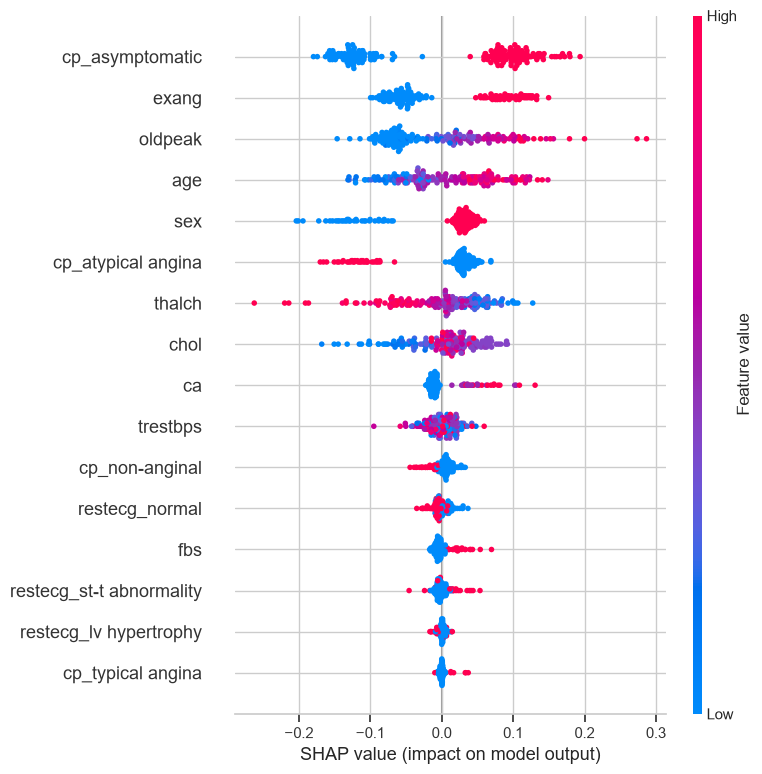

In [85]:
import shap

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_processed)

if isinstance(shap_values, list):
    shap_values_disease = shap_values[1]
else:
    shap_values_disease = shap_values[:, :, 1]

shap.summary_plot(shap_values_disease, X_test_processed, feature_names=final_columns)

In [86]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42)

xgb_model.fit(X_train_processed, y_train)

y_pred_xgb = xgb_model.predict(X_test_processed)

print("--- XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

--- XGBoost Performance ---
Accuracy: 0.8152

Confusion Matrix:
[[63 19]
 [15 87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        82
           1       0.82      0.85      0.84       102

    accuracy                           0.82       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.81      0.82      0.81       184



--- XGBoost SHAP Feature Importance ---


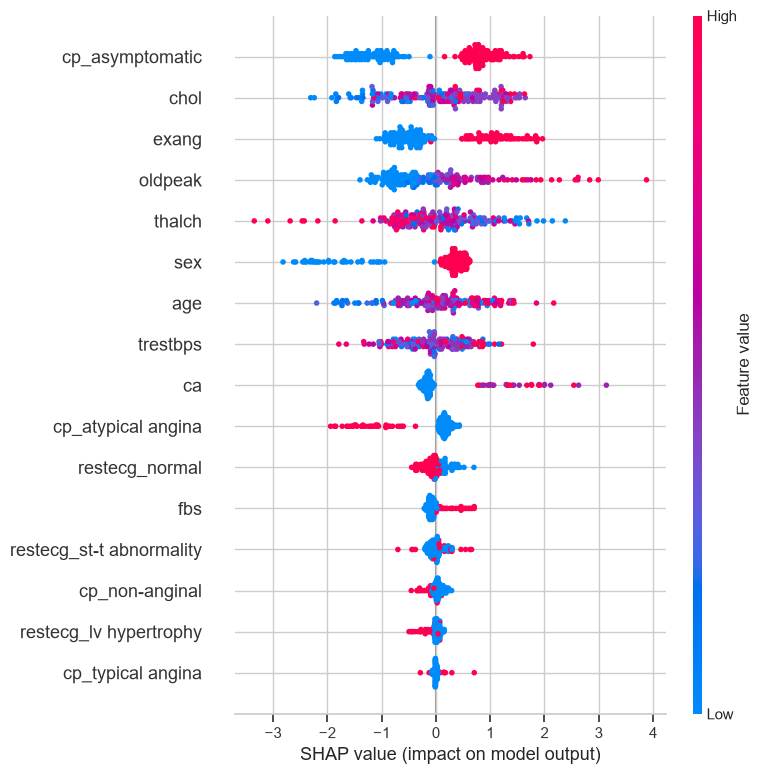

In [87]:
import shap

xgb_explainer = shap.TreeExplainer(xgb_model)

xgb_shap_values = xgb_explainer.shap_values(X_test_processed)

if isinstance(xgb_shap_values, list):
    xgb_shap_values_disease = xgb_shap_values[1]
elif len(xgb_shap_values.shape) == 3:
    xgb_shap_values_disease = xgb_shap_values[:, :, 1]
else:
    xgb_shap_values_disease = xgb_shap_values

print("--- XGBoost SHAP Feature Importance ---")
shap.summary_plot(xgb_shap_values_disease, X_test_processed, feature_names=final_columns)